<a href="https://colab.research.google.com/github/Hangyeol82/Computer_Vision/blob/main/C_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%92%E1%85%A5%E1%86%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실험 C] 최적화 알고리즘 비교 : SGD, SGD+Momentum, Adam



In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# ============================================================
# 1. Seed 고정
# ============================================================

# 실험 재현성을 위해 seed를 고정한다.
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# ============================================================
# 2. Digits Dataset 로딩
# ============================================================

def load_digits_dataset(batch_size=64):
    # Digits Dataset은 8x8 숫자 이미지 데이터셋이며 MLP 입력 크기는 64
    digits = load_digits()

    X = digits.data.astype(np.float32)
    y = digits.target.astype(np.int64)

    # 입력 feature의 스케일을 맞춰 학습을 안정화
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader, 64, 10


train_loader, test_loader, input_size, num_classes = load_digits_dataset()

In [4]:
# ============================================================
# 3. MLP 모델 정의
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_size=64, num_classes=10):
        super().__init__()

        # optimizer의 영향만 비교하기 위해 모든 실험에서 동일한 MLP 구조를 사용
        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [5]:
# ============================================================
# 4. 평가 함수
# ============================================================

def evaluate_model(model, test_loader):
    # 평가 과정에서는 gradient 계산이 필요 없으므로 eval/no_grad를 사용한다
    model.eval()

    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(test_loader), correct / total

In [6]:
# ============================================================
# 5. Optimizer 생성 함수
# ============================================================

def create_optimizer(model, optimizer_name, lr):
    # optimizer 종류만 바꿔 동일한 네트워크에서 학습 패턴 차이를 비교
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

    else:
        raise ValueError("지원하지 않는 optimizer입니다.")

    return optimizer

In [7]:
# ============================================================
# 6. 학습 함수
# ============================================================

def train_model(
    model,
    train_loader,
    test_loader,
    optimizer_name,
    lr,
    epochs=50,
    use_scheduler=True
):
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = create_optimizer(
        model=model,
        optimizer_name=optimizer_name,
        lr=lr
    )

    # Exponential Decay는 학습 후반부의 안정적인 수렴 여부를 확인하기 위해 사용
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimizer,
            gamma=0.9
        )

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "grad_norms": [],
        "learning_rates": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0
        epoch_grad_norms = []

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            loss.backward()

            # optimizer에 따라 gradient 흐름과 업데이트 안정성이 어떻게 달라지는지 확인한다.
            grad_norm = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    grad_norm += param.grad.norm().item()

            epoch_grad_norms.append(grad_norm)

            optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        test_loss, test_acc = evaluate_model(
            model,
            test_loader
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["grad_norms"].append(np.mean(epoch_grad_norms))
        history["learning_rates"].append(optimizer.param_groups[0]["lr"])

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1:03d}/{epochs}] "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.4f} | "
                f"LR: {optimizer.param_groups[0]['lr']:.6f}"
            )

    return history

In [8]:
# ============================================================
# 7. 실험 설정
# ============================================================

# 각 optimizer의 일반적인 권장 learning rate 범위를 반영하여 실험한다.
experiment_settings = [
    {
        "name": "SGD_lr_0.1",
        "optimizer": "SGD",
        "lr": 0.1
    },
    {
        "name": "SGD_lr_0.01",
        "optimizer": "SGD",
        "lr": 0.01
    },
    {
        "name": "SGD_lr_0.001",
        "optimizer": "SGD",
        "lr": 0.001
    },
    {
        "name": "Momentum_lr_0.1",
        "optimizer": "Momentum",
        "lr": 0.1
    },
    {
        "name": "Momentum_lr_0.01",
        "optimizer": "Momentum",
        "lr": 0.01
    },
    {
        "name": "Momentum_lr_0.001",
        "optimizer": "Momentum",
        "lr": 0.001
    },
    {
        "name": "Adam_lr_0.1",
        "optimizer": "Adam",
        "lr": 0.1
    },
    {
        "name": "Adam_lr_0.01",
        "optimizer": "Adam",
        "lr": 0.01
    },
    {
        "name": "Adam_lr_0.001",
        "optimizer": "Adam",
        "lr": 0.001
    }
]

In [9]:
# ============================================================
# 8. 전체 Optimizer 실험 실행
# ============================================================

histories = {}
models = {}

for setting in experiment_settings:
    print(f"\n========== {setting['name']} 실험 시작 ==========")

    # 동일한 초기 가중치 조건에서 optimizer 차이만 비교하기 위해 seed를 매번 고정한다.
    set_seed(42)

    model = MLP(
        input_size=input_size,
        num_classes=num_classes
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer_name=setting["optimizer"],
        lr=setting["lr"],
        epochs=50,
        use_scheduler=True
    )

    histories[setting["name"]] = history
    models[setting["name"]] = model


========== SGD_lr_0.1 실험 시작 ==========
Epoch [001/50] Train Loss: 2.0679 | Train Acc: 0.5261 | Test Loss: 1.7219 | Test Acc: 0.7083 | LR: 0.090000
Epoch [010/50] Train Loss: 0.1567 | Train Acc: 0.9715 | Test Loss: 0.1730 | Test Acc: 0.9500 | LR: 0.034868
Epoch [020/50] Train Loss: 0.0964 | Train Acc: 0.9847 | Test Loss: 0.1355 | Test Acc: 0.9583 | LR: 0.012158
Epoch [030/50] Train Loss: 0.0825 | Train Acc: 0.9889 | Test Loss: 0.1282 | Test Acc: 0.9639 | LR: 0.004239
Epoch [040/50] Train Loss: 0.0803 | Train Acc: 0.9903 | Test Loss: 0.1258 | Test Acc: 0.9639 | LR: 0.001478
Epoch [050/50] Train Loss: 0.0774 | Train Acc: 0.9903 | Test Loss: 0.1251 | Test Acc: 0.9639 | LR: 0.000515

========== SGD_lr_0.01 실험 시작 ==========
Epoch [001/50] Train Loss: 2.2763 | Train Acc: 0.1726 | Test Loss: 2.2543 | Test Acc: 0.2139 | LR: 0.009000
Epoch [010/50] Train Loss: 1.9820 | Train Acc: 0.6792 | Test Loss: 1.9746 | Test Acc: 0.6750 | LR: 0.003487
Epoch [020/50] Train Loss: 1.7996 | Train Acc: 0.7182 |

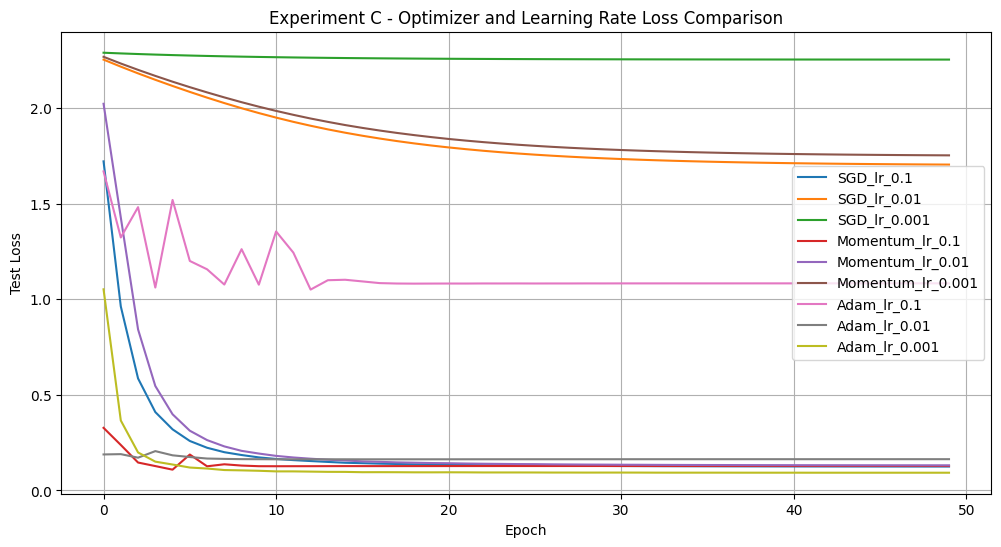

In [10]:
# ============================================================
# 9. 전체 Loss 그래프
# ============================================================

# optimizer와 learning rate 조합별 loss 감소 속도와 진동 여부를 비교한다.
plt.figure(figsize=(12, 6))

for name, history in histories.items():
    plt.plot(history["test_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment C - Optimizer and Learning Rate Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

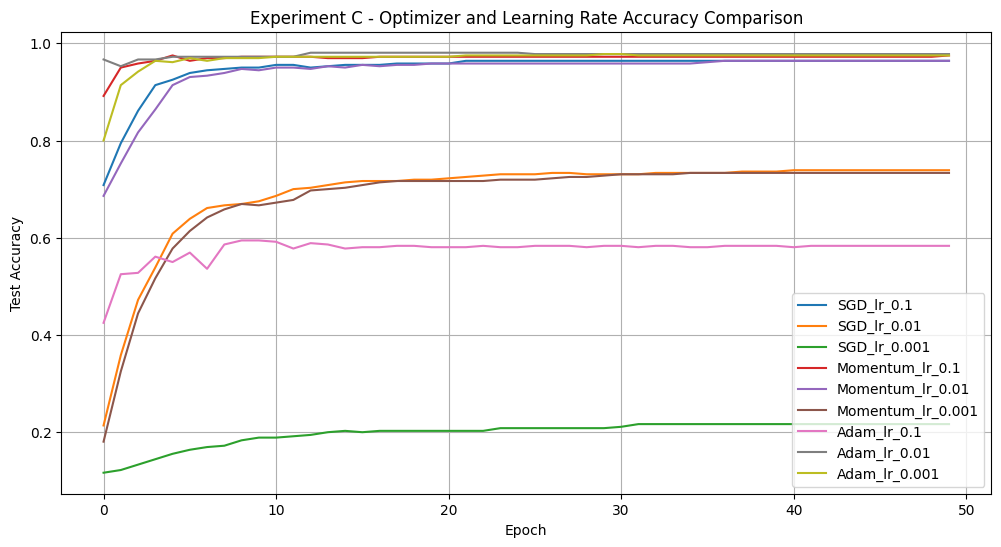

In [11]:
# ============================================================
# 10. 전체 Accuracy 그래프
# ============================================================

# optimizer와 learning rate 조합별 정확도 상승 속도와 최종 성능을 비교한다.
plt.figure(figsize=(12, 6))

for name, history in histories.items():
    plt.plot(history["test_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment C - Optimizer and Learning Rate Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# ============================================================
# 11. 정량 비교 표 생성
# ============================================================

def get_convergence_epoch(acc_list):
    final_acc = acc_list[-1]
    target_acc = final_acc * 0.95

    for i, acc in enumerate(acc_list):
        if acc >= target_acc:
            return i + 1

    return len(acc_list)


summary_rows = []

for setting in experiment_settings:
    name = setting["name"]
    history = histories[name]

    summary_rows.append({
        "Experiment": name,
        "Optimizer": setting["optimizer"],
        "Initial LR": setting["lr"],
        "Final Accuracy (%)": round(history["test_acc"][-1] * 100, 2),
        "Min Loss": round(min(history["test_loss"]), 4),
        "Convergence Epoch": get_convergence_epoch(history["test_acc"]),
        "Final Gradient Norm": round(history["grad_norms"][-1], 6)
    })

summary_C = pd.DataFrame(summary_rows)
summary_C

,Experiment,Optimizer,Initial LR,Final Accuracy (%),Min Loss,Convergence Epoch,Final Gradient Norm
0,SGD_lr_0.1,SGD,0.100,96.39,0.1251,5,0.624933
1,SGD_lr_0.01,SGD,0.010,73.89,1.7050,13,1.640551
2,SGD_lr_0.001,SGD,0.001,21.67,2.2545,24,1.185404
3,Momentum_lr_0.1,Momentum,0.100,97.50,0.1088,2,0.022059
4,Momentum_lr_0.01,Momentum,0.010,96.39,0.1315,6,0.663358
5,Momentum_lr_0.001,Momentum,0.001,73.33,1.7534,13,1.611456
6,Adam_lr_0.1,Adam,0.100,58.33,1.0510,4,0.073385
7,Adam_lr_0.01,Adam,0.010,97.78,0.1629,1,0.003785
8,Adam_lr_0.001,Adam,0.001,97.50,0.0928,3,0.194423


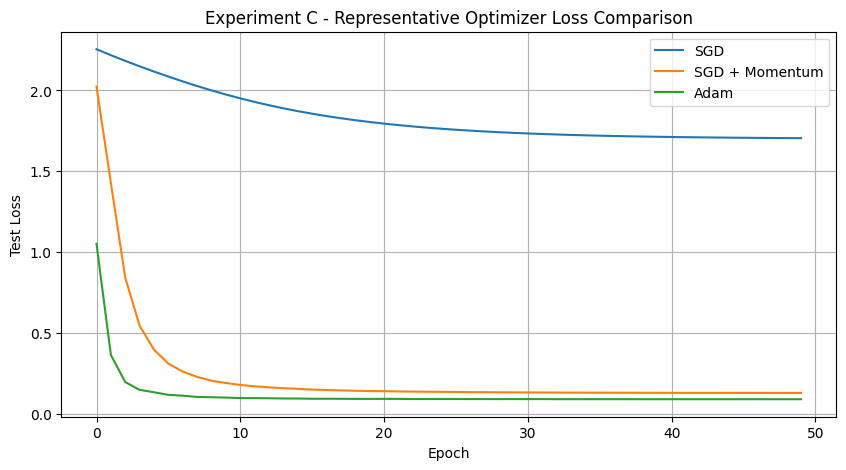

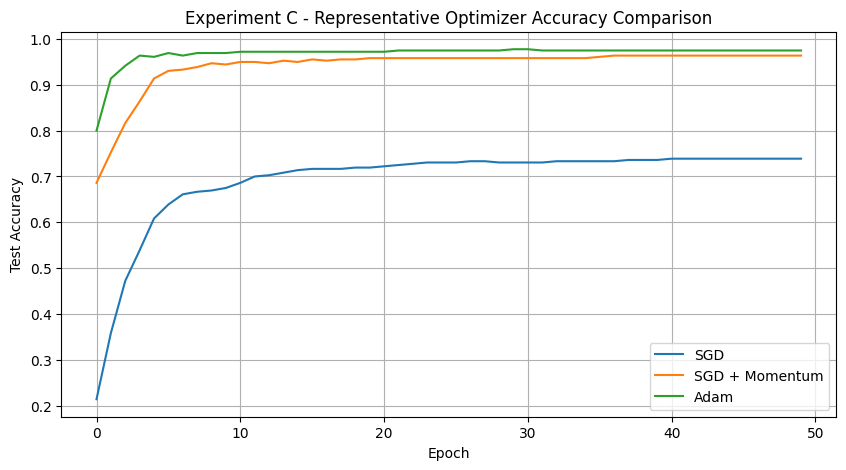

In [13]:
# ============================================================
# 12. 대표 Optimizer 비교
# ============================================================

# 보고서에는 대표 learning rate 조건의 세 optimizer를 비교하면 해석이 깔끔하다.
representative_histories = {
    "SGD": histories["SGD_lr_0.01"],
    "SGD + Momentum": histories["Momentum_lr_0.01"],
    "Adam": histories["Adam_lr_0.001"]
}

# 대표 optimizer의 loss 감소 패턴을 비교한다.
plt.figure(figsize=(10, 5))

for name, history in representative_histories.items():
    plt.plot(history["test_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment C - Representative Optimizer Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 대표 optimizer의 정확도 상승 속도와 최종 성능을 비교한다.
plt.figure(figsize=(10, 5))

for name, history in representative_histories.items():
    plt.plot(history["test_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment C - Representative Optimizer Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# ============================================================
# 13. 대표 Optimizer 정량 비교 표
# ============================================================

representative_rows = []

representative_settings = [
    {
        "name": "SGD_lr_0.01",
        "display": "SGD"
    },
    {
        "name": "Momentum_lr_0.01",
        "display": "SGD + Momentum"
    },
    {
        "name": "Adam_lr_0.001",
        "display": "Adam"
    }
]

for item in representative_settings:
    history = histories[item["name"]]

    representative_rows.append({
        "Optimizer": item["display"],
        "Final Accuracy (%)": round(history["test_acc"][-1] * 100, 2),
        "Min Loss": round(min(history["test_loss"]), 4),
        "Convergence Epoch": get_convergence_epoch(history["test_acc"]),
        "Final Gradient Norm": round(history["grad_norms"][-1], 6)
    })

summary_C_representative = pd.DataFrame(representative_rows)
summary_C_representative

,Optimizer,Final Accuracy (%),Min Loss,Convergence Epoch,Final Gradient Norm
0,SGD,73.89,1.7050,13,1.640551
1,SGD + Momentum,96.39,0.1315,6,0.663358
2,Adam,97.50,0.0928,3,0.194423


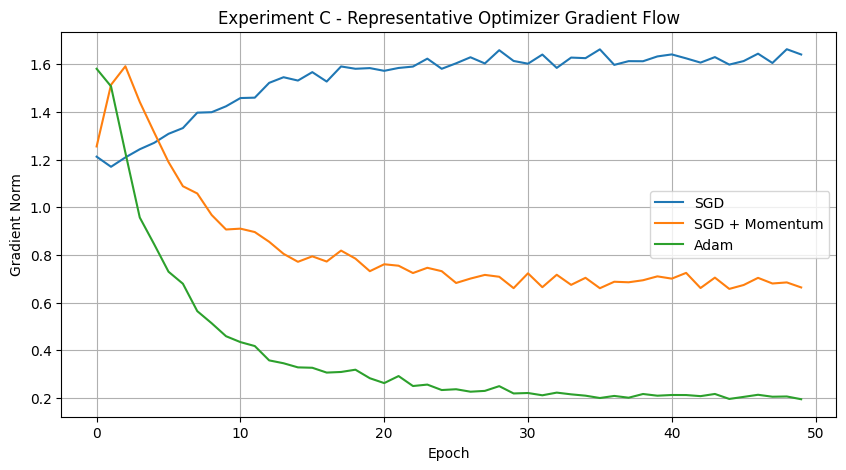

In [15]:
# ============================================================
# 14. Gradient Flow 비교
# ============================================================

# optimizer별 gradient norm 변화를 통해 업데이트 신호의 안정성을 비교한다.
plt.figure(figsize=(10, 5))

for name, history in representative_histories.items():
    plt.plot(history["grad_norms"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Experiment C - Representative Optimizer Gradient Flow")
plt.legend()
plt.grid(True)
plt.show()

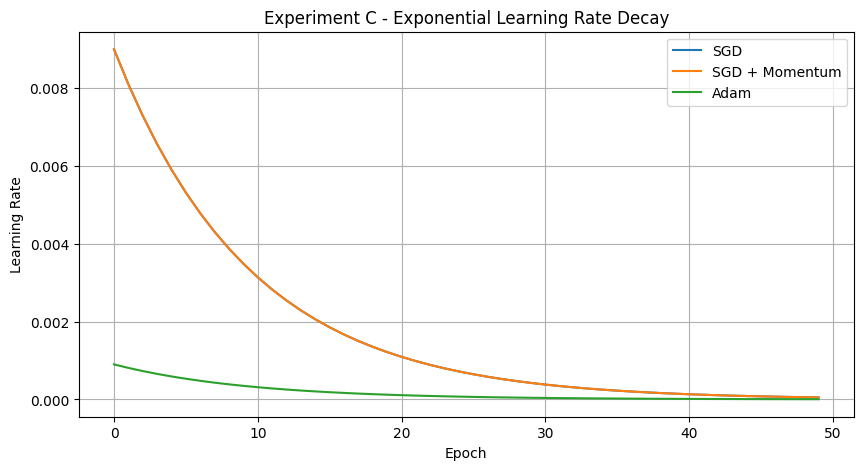

In [16]:
# ============================================================
# 15. Learning Rate Decay 확인
# ============================================================

# ExponentialLR이 epoch마다 learning rate를 감소시키는지 확인한다.
plt.figure(figsize=(10, 5))

for name, history in representative_histories.items():
    plt.plot(history["learning_rates"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Experiment C - Exponential Learning Rate Decay")
plt.legend()
plt.grid(True)
plt.show() # SGD는 SGD + Momentum과 완벽하게 겹침

In [17]:
# ============================================================
# 16. Optimizer별 Learning Rate 성능 비교 Pivot Table
# ============================================================

# learning rate 변화에 따라 optimizer 성능이 어떻게 달라지는지 표로 정리한다.
pivot_acc = summary_C.pivot_table(
    index="Optimizer",
    columns="Initial LR",
    values="Final Accuracy (%)"
)

pivot_loss = summary_C.pivot_table(
    index="Optimizer",
    columns="Initial LR",
    values="Min Loss"
)

print("Final Accuracy Pivot Table")
display(pivot_acc)

print("Min Loss Pivot Table")
display(pivot_loss)

Final Accuracy Pivot Table


Initial LR,0.001,0.010,0.100
Optimizer,,,
Adam,97.50,97.78,58.33
Momentum,73.33,96.39,97.50
SGD,21.67,73.89,96.39


Min Loss Pivot Table


Initial LR,0.001,0.010,0.100
Optimizer,,,
Adam,0.0928,0.1629,1.0510
Momentum,1.7534,0.1315,0.1088
SGD,2.2545,1.7050,0.1251
